In [1]:
# Import library dasar untuk manipulasi data dan visualisasi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import library dari Scikit-Learn untuk Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Membaca dataset
# Sesuaikan path/lokasi file jika ada di dalam folder data/dataset/
df = pd.read_csv('mushrooms.csv')

# Menampilkan 5 baris pertama untuk memastikan data terbaca
display(df.head())

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Ukuran dataset: (8124, 23)


/tmp/ipykernel_2116/4139061682.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', palette='Set2')


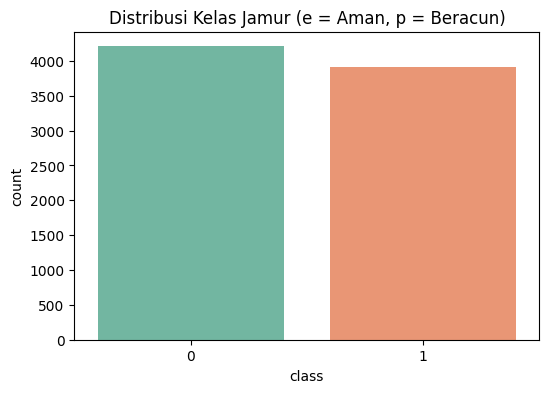

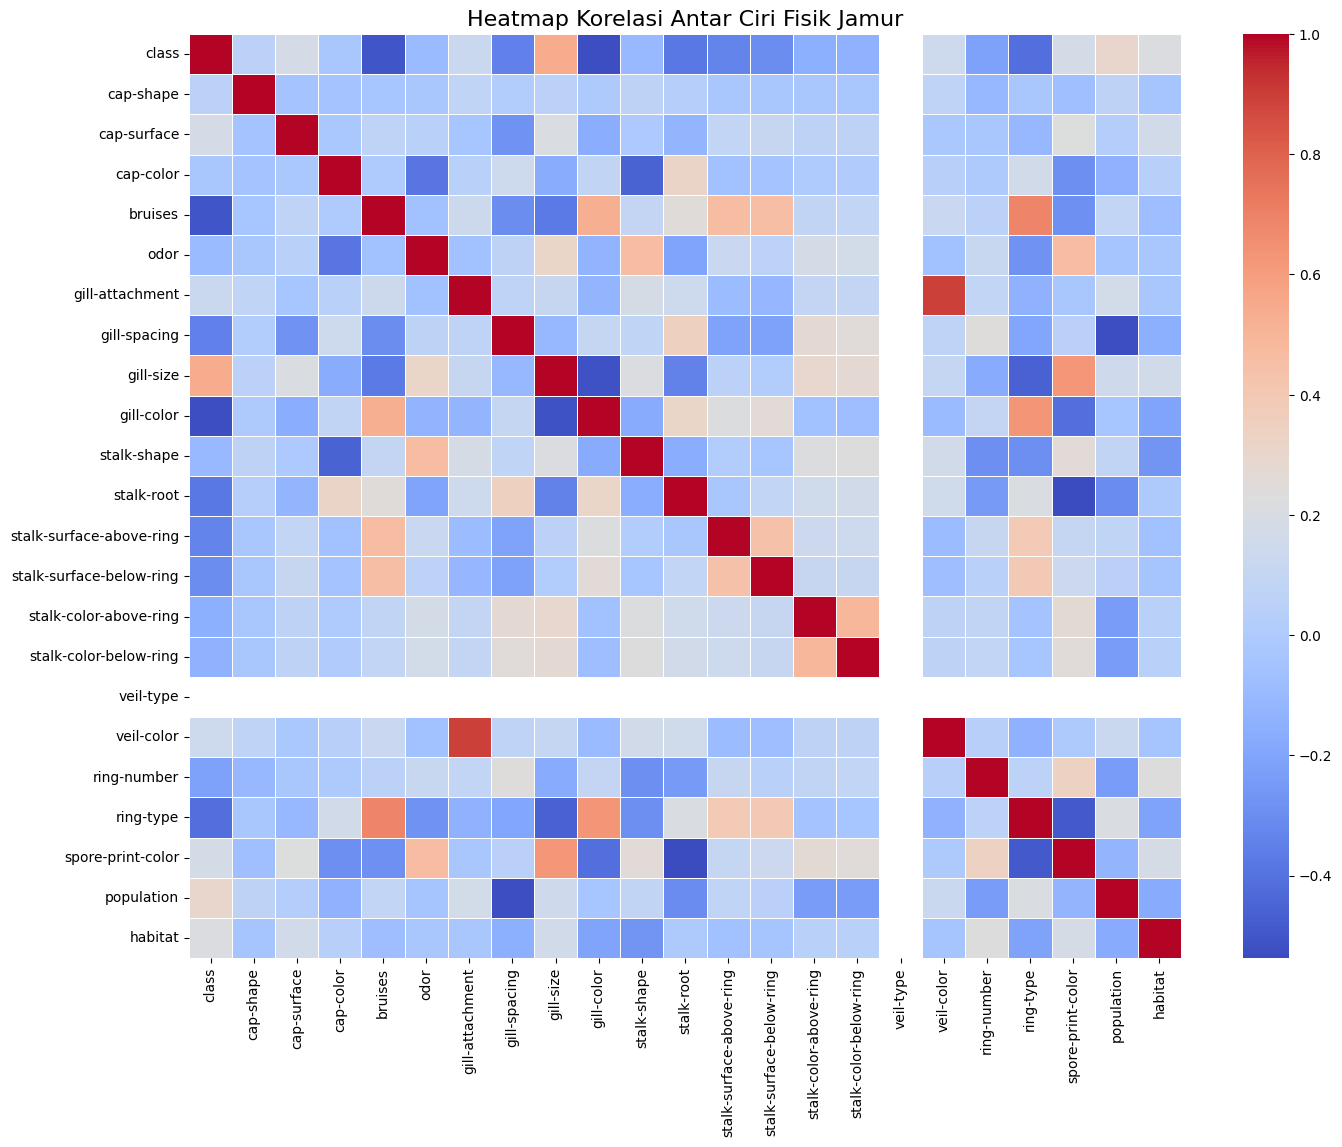

Korelasi fitur terhadap kelas (beracun/tidak):
class                       1.000000
gill-size                   0.540024
population                  0.298686
habitat                     0.217179
cap-surface                 0.178446
spore-print-color           0.171961
veil-color                  0.145142
gill-attachment             0.129200
cap-shape                   0.052951
cap-color                  -0.031384
odor                       -0.093552
stalk-shape                -0.102019
stalk-color-below-ring     -0.146730
stalk-color-above-ring     -0.154003
ring-number                -0.214366
stalk-surface-below-ring   -0.298801
stalk-surface-above-ring   -0.334593
gill-spacing               -0.348387
stalk-root                 -0.379361
ring-type                  -0.411771
bruises                    -0.501530
gill-color                 -0.530566
veil-type                        NaN
Name: class, dtype: float64


In [13]:
# Melihat ukuran data (baris, kolom)
print(f"Ukuran dataset: {df.shape}")

# Visualisasi distribusi kelas target (e = edible/aman, p = poisonous/beracun)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', palette='Set2')
plt.title('Distribusi Kelas Jamur (e = Aman, p = Beracun)')
plt.show()


# Membuat salinan (copy) data agar data asli teks tidak rusak
df_heatmap = df.copy()

# Mengubah teks menjadi angka menggunakan LabelEncoder khusus untuk heatmap ini
encoder_heatmap = LabelEncoder()
for col in df_heatmap.columns:
    df_heatmap[col] = encoder_heatmap.fit_transform(df_heatmap[col])

# Menghitung nilai korelasi antar semua kolom (fitur)
korelasi = df_heatmap.corr()

# Mengatur ukuran kanvas gambar (dibuat agak besar karena ada 23 kolom)
plt.figure(figsize=(16, 12))

# Menggambar Heatmap
# annot=False agar angka tidak bertumpuk karena kolom terlalu banyak
# cmap='coolwarm' akan memberi warna biru untuk korelasi rendah, dan merah untuk korelasi tinggi
sns.heatmap(korelasi, annot=False, cmap='coolwarm', linewidths=0.5, fmt=".2f")

# Memberi judul grafik
plt.title('Heatmap Korelasi Antar Ciri Fisik Jamur', fontsize=16)

# Menampilkan grafik
plt.show()

# (Opsional) Melihat korelasi angka spesifik terhadap kolom 'class' (beracun/tidak)
print("Korelasi fitur terhadap kelas (beracun/tidak):")
print(korelasi['class'].sort_values(ascending=False))

In [12]:
# Inisialisasi LabelEncoder
encoder = LabelEncoder()

# Melakukan perulangan untuk mengubah setiap kolom teks menjadi angka
for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

# Memisahkan Fitur (X) dan Target Kelas (y)
X = df.drop('class', axis=1) # Mengambil semua kolom kecuali kolom 'class'
y = df['class']              # Hanya mengambil kolom 'class' (0 = aman, 1 = beracun)

# Membagi data menjadi 80% Data Latih (Train) dan 20% Data Uji (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji: {X_test.shape[0]}")

Jumlah data latih: 6499
Jumlah data uji: 1625


In [14]:
# 1.Pelatihan Model Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train) # Proses AI belajar dari data latih

# 2.Pelatihan Model Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train) # Proses AI belajar dari data latih

y_pred_dt = dt_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)

=== Evaluasi Model: Decision Tree ===
Akurasi: 1.0000

Laporan Klasifikasi (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



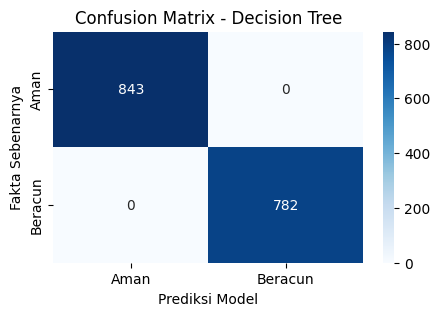

--------------------------------------------------
=== Evaluasi Model: Naive Bayes ===
Akurasi: 0.9218

Laporan Klasifikasi (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       843
           1       0.91      0.93      0.92       782

    accuracy                           0.92      1625
   macro avg       0.92      0.92      0.92      1625
weighted avg       0.92      0.92      0.92      1625



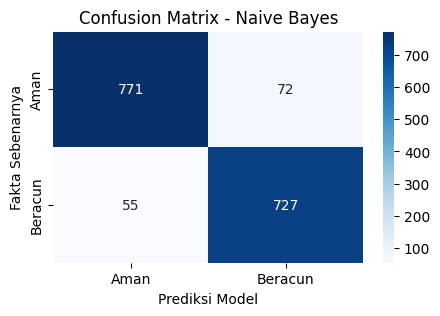

--------------------------------------------------


In [6]:
# Fungsi bantuan untuk menampilkan metrik evaluasi
def evaluate_model(y_true, y_pred, model_name):
    print(f"=== Evaluasi Model: {model_name} ===")
    print(f"Akurasi: {accuracy_score(y_true, y_pred):.4f}")
    print("\nLaporan Klasifikasi (Precision, Recall, F1-Score):")
    print(classification_report(y_true, y_pred))

    # Membuat visualisasi Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Aman', 'Beracun'], yticklabels=['Aman', 'Beracun'])
    plt.xlabel('Prediksi Model')
    plt.ylabel('Fakta Sebenarnya')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    print("-" * 50)

# Mengevaluasi Decision Tree
evaluate_model(y_test, y_pred_dt, "Decision Tree")

# Mengevaluasi Naive Bayes
evaluate_model(y_test, y_pred_nb, "Naive Bayes")

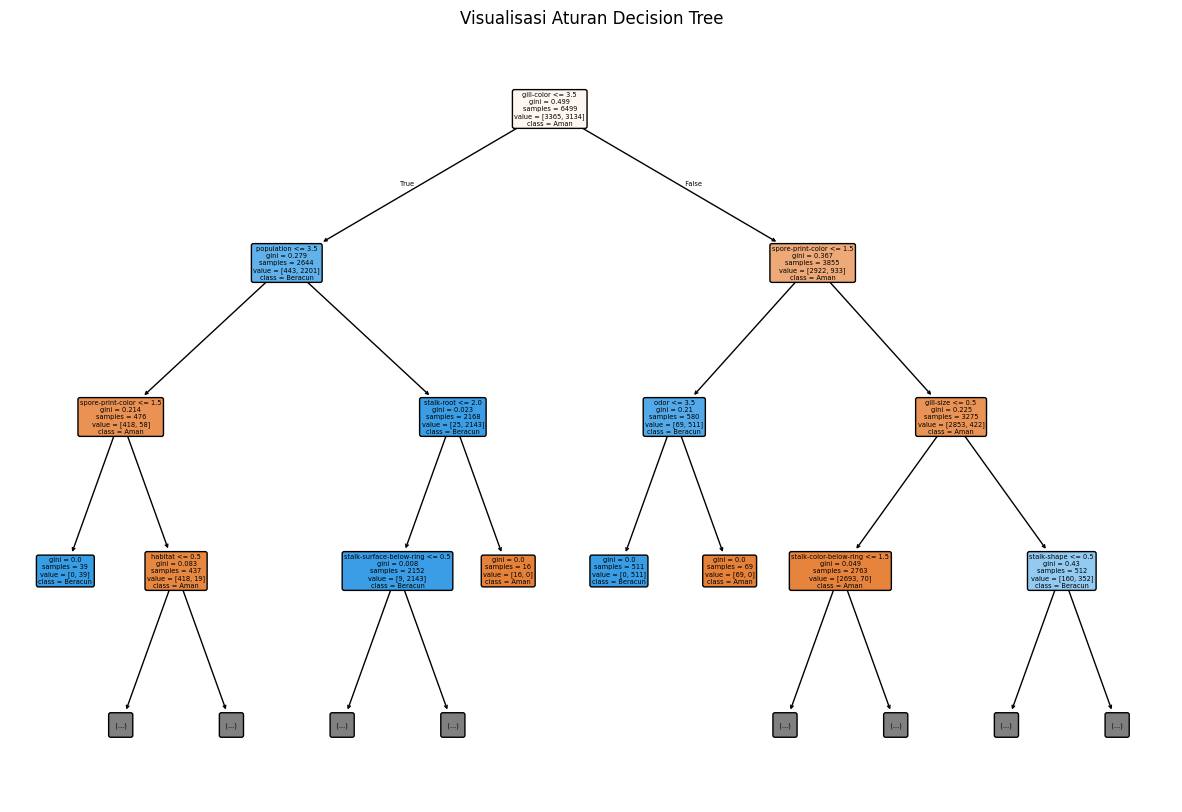

In [7]:
# Plot sebagian dari pohon keputusan (kedalaman maksimal 3 agar gambar tidak terlalu padat)
plt.figure(figsize=(15, 10))
plot_tree(dt_model, filled=True, feature_names=df.columns.drop('class'),
          class_names=['Aman', 'Beracun'], max_depth=3, rounded=True)
plt.title("Visualisasi Aturan Decision Tree")
plt.show()